# 1、执行了RODM-STATIC模型的网格无关性验证。2024年12月26日

In [30]:
#import packages
import time
import numpy as np
import capytaine as cpt
import scipy
from capytaine.io.mesh_writers import write_STL
import matplotlib.pyplot as plt
from scipy.linalg import block_diag
from scipy.linalg import eigh
import vtk
import logging
import xarray as xr
from capytaine.io.xarray import merge_complex_values
from capytaine.post_pro import rao
logging.basicConfig(level=logging.INFO, format='%(levelname)-8s: %(message)s')
# user defined functions
import DM_ShowNodes as DMshow
import DM_Reading as dm_r
import DM_Assemble as DM_A
import SEREP as SEREP
import DM_Method as DM_M
import pandas as pd

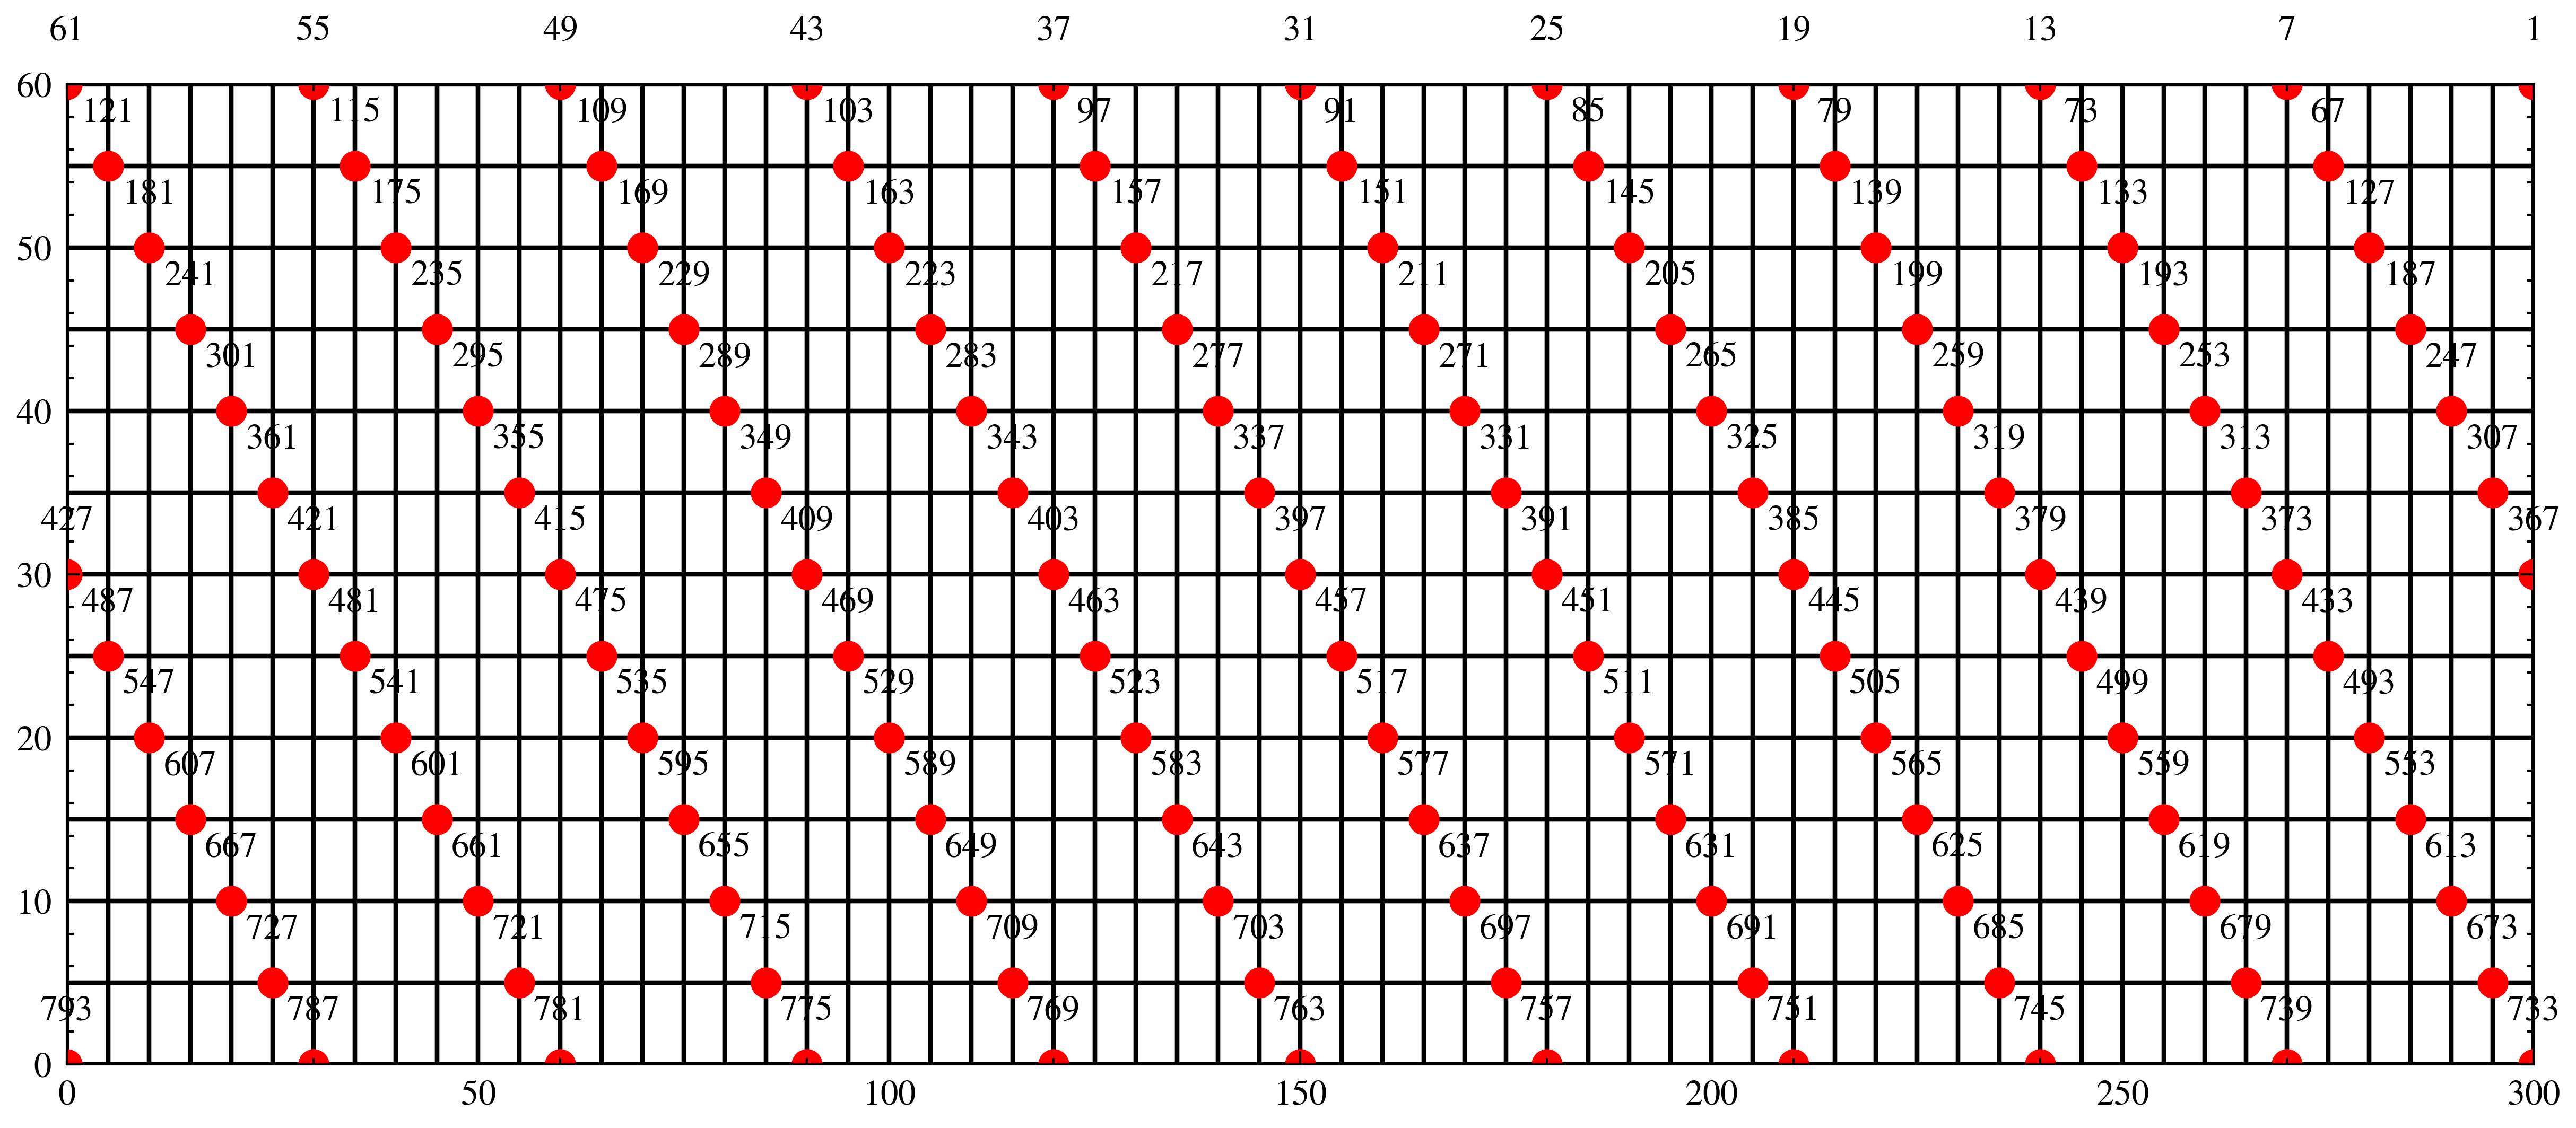

In [16]:
# Show nodes and node message
file_path = "E:\phd\Code\DM-FEM2D\Fem_inp\JobMesh5_5.inp"
label_interval = 6
node = DMshow.plot_fea_model(file_path, label_interval)
#node_ids = [41, 39, 37, 35, 33, 31, 29, 27, 25, 23]

### 1.Mesh:5*5 , 施加力节点为 DM_A.calculate_node_positions(424,6,10) ， 节点数为793
### 2.Mesh:3*3 , 施加力节点为 DM_A.calculate_node_positions(1106,10,10)， 节点数为2121
### 3.Mesh:1*1 , 施加力节点为 DM_A.calculate_node_positions(9316,30,10),  节点数18361 ,消耗内存太多，不能在台式机上进行计算。
### 4.Mehs:coarse model, 施加力节点为[41, 39, 37, 35, 33, 31, 29, 27, 25, 23] , 节点数63

In [45]:
# define parameters
num_nodes = 63 # 63 793 2121
master_nodes = [41, 39, 37, 35, 33, 31, 29, 27, 25, 23]  #[41, 39, 37, 35, 33, 31, 29, 27, 25, 23] DM_A.calculate_node_positions(425,6,10) DM_A.calculate_node_positions(1106,10,10)
dataset = merge_complex_values(xr.open_dataset("E:\phd\Code\DM-FEM2D\HydrodynamicData\Yoga\DM10_300_direction0.nc"))
omega = dataset.omega.values
Area = 1025*9.81*30*15
nodes_per_row = 21
# read mass and stiffness matrix
file_m = 'E:\phd\Code\DM-FEM2D\StructureData\Job-1_largemesh_ConsistentMass_MASS1.mtx'
file_k = 'E:\phd\Code\DM-FEM2D\StructureData\Job-1_largemesh_STIF1.mtx' 
M = dm_r.get_stiffness_matrix(file_m)
k = dm_r.get_stiffness_matrix(file_k)

# reduce dofs
M_consistant= SEREP.reduce_dofs(M, num_nodes, [5])
k = SEREP.reduce_dofs(k, num_nodes, [5])

# transform mass matrix, beta=0 is consistant mass matrix
M = SEREP.transform_mass_matrix(M_consistant,beta=0)
# obtaine master dofs and slave dofs
MasterDofs, SlaveDofs = SEREP.separate_dofs(num_nodes, master_nodes)

# reduce matrix use SEREP
#MR,KR,T = SEREP.SEREP(k, M, SlaveDofs,master_nodes)
MR, KR, T = SEREP.static_condensation(k, M, MasterDofs, SlaveDofs)
# read hydrodynamic data
added_mass = dataset['added_mass'][0].values
radiation_damping = dataset['radiation_damping'][0].values
inertia_matrix = dataset['inertia_matrix'].values
# hydrostatic_stiffness = dataset['hydrostatic_stiffness'].values
F_w = dataset['Froude_Krylov_force'][0].values + dataset['diffraction_force'][0].values
# REDUCE THE MATRICES
added_mass = SEREP.reduce_dofs(added_mass,10,[5])
radiation_damping = SEREP.reduce_dofs(radiation_damping,10,[5])
# hyrostatic stiffness or fem spring stiffness
# 1. choice hydrostatic stiffness
hydrostatic_stiffness = dataset['hydrostatic_stiffness'].values
hydrostatic_stiffness = SEREP.reduce_dofs(hydrostatic_stiffness,10,[5])
# 2. choice fem spring stiffness
# hydrostatic_stiffness = SEREP.get_fem_spring_stiffness(num_nodes, nodes_per_row, Area)
# hydrostatic_stiffness = SEREP.reduce_dofs(hydrostatic_stiffness,num_nodes,[5])
# hydrostatic_stiffness = T.T @ hydrostatic_stiffness @ T

inertia_matrix = SEREP.reduce_dofs(inertia_matrix,10,[5])
F_w = SEREP.reduce_force_matrix_dofs(F_w, 10, 5).reshape(1,50)
# F_w = F_w.reshape(10,5)[::-1].reshape(1,50)
# Generate the system matrices
mass = added_mass + MR
damping = radiation_damping
stiffness =  hydrostatic_stiffness + KR
# Solve in frequency domain
master_displacement = DM_A.solve_frequency_domain(mass, damping, stiffness, F_w, omega)
# Restore global displacement under disorder masterdofs and slavedofs
global_displacement_disorder = T @ master_displacement
master_displacement = master_displacement.reshape(len(master_nodes), 5)[::-1].reshape(5 * len(master_nodes), 1)
# Reorder global displacement under order
global_displacement_error = SEREP.reorder_displacement_matrix(global_displacement_disorder, MasterDofs, SlaveDofs)
global_displacement = DM_M.replace_master_with_global(master_displacement, global_displacement_error, master_nodes)

In [47]:
np.save('displacement_1530mesh_300.npy', global_displacement)


## 验证工作

Text(0, 0.5, 'Heave RAO ($m$/$m$)')

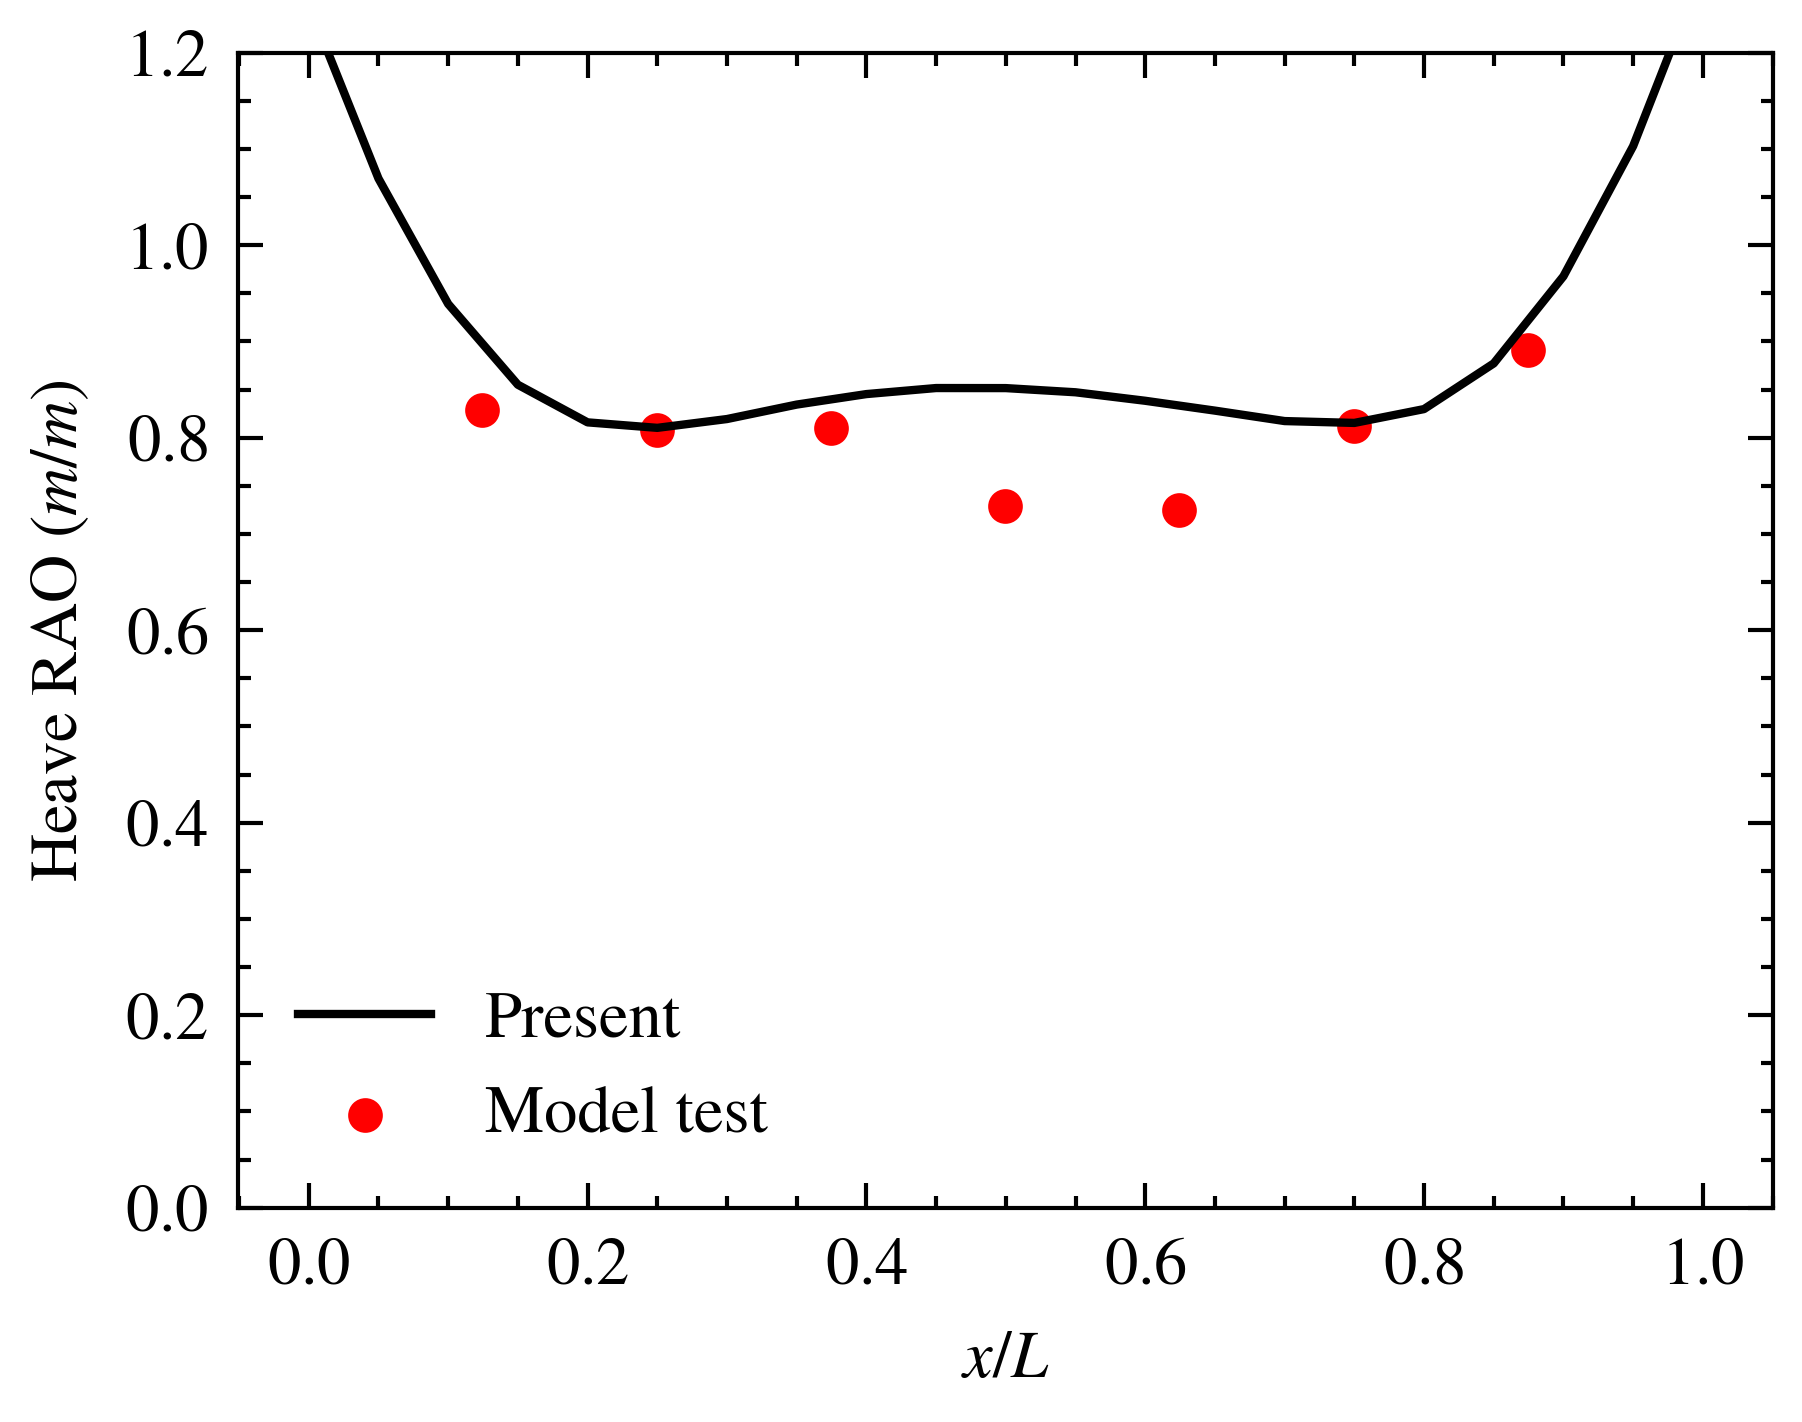

In [46]:
import matplotlib.pyplot as plt
mid = global_displacement[22*5-5:43*5-5,:]
heave = abs(mid[2::5])

# 与实验结果进行对比、绘图
from DM_Verify import process_exp_data
x, y = process_exp_data("E:\phd\Code\DM-FEM2D\data\Experiment_300_60\exp_300.txt")
y = np.array(y)
# 绘图
import scienceplots
x1 = np.linspace(0,1,21)
plt.style.use(['science','no-latex','ieee'])
plt.plot(x1,abs(mid[2::5]), label="Present")
plt.scatter(x,y,color = 'red',label="Model test",s=10)
plt.legend() 
plt.ylim(0,1.2) # 调整y轴坐标
plt.xlabel(r'$x/L$',)
plt.ylabel(r'Heave RAO ($m$/$m$)')

Text(0, 0.5, 'Heave RAO ($m$/$m$)')

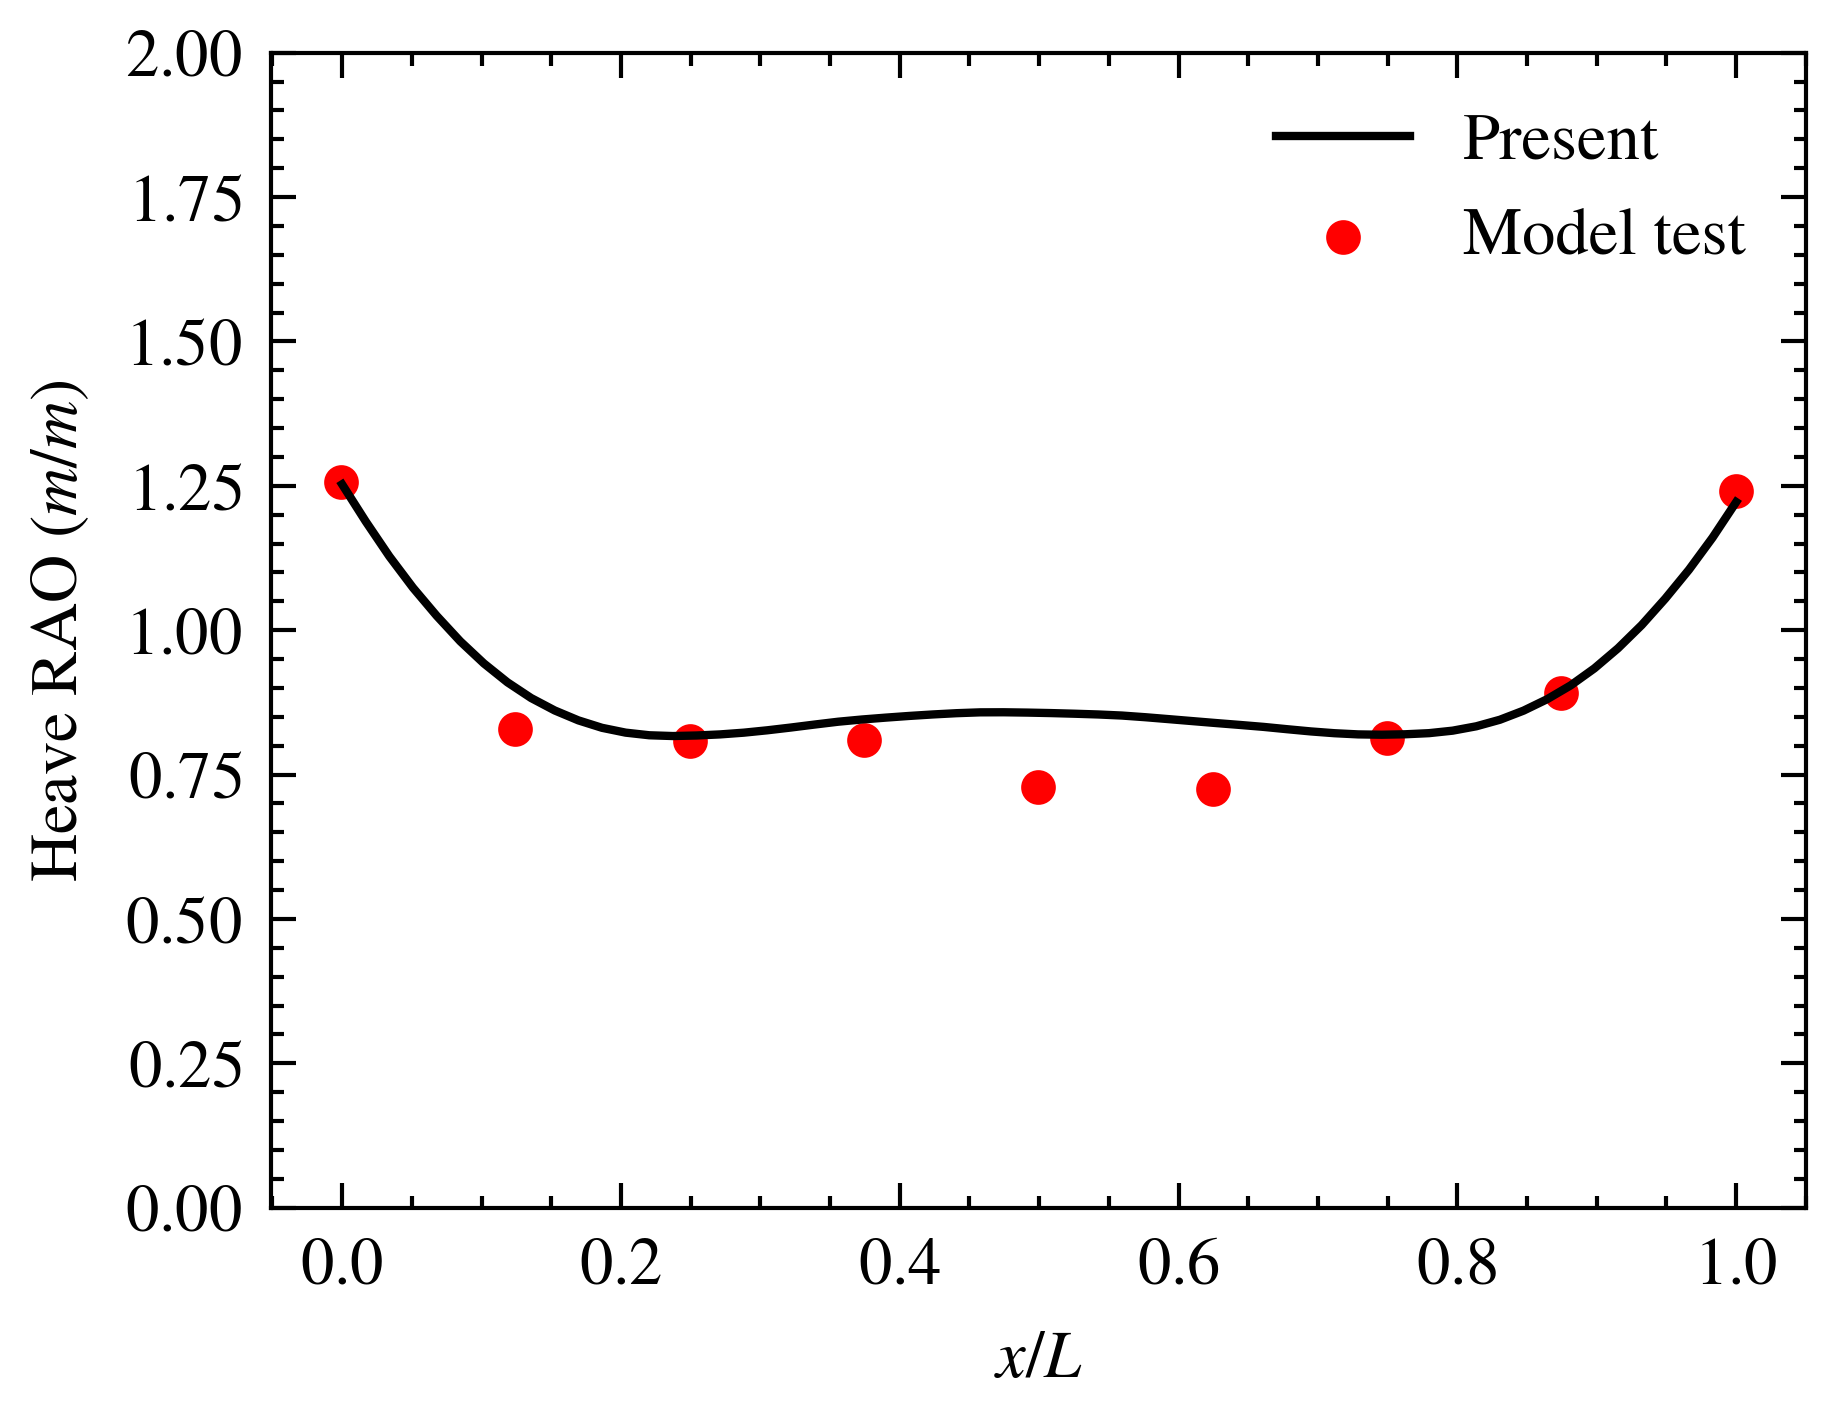

In [39]:
import matplotlib.pyplot as plt
mid = global_displacement[367*5-5:427*5-5,:]
heave = abs(mid[2::5])

# 与实验结果进行对比、绘图
from DM_Verify import process_exp_data
x, y = process_exp_data("E:\phd\Code\DM-FEM2D\data\Experiment_300_60\exp_300.txt")
y = np.array(y)
# 绘图
import scienceplots
x1 = np.linspace(0,1,60)
plt.style.use(['science','no-latex','ieee'])
plt.plot(x1,abs(mid[2::5]), label="Present")
plt.scatter(x,y,color = 'red',label="Model test",s=10)
plt.legend() 
plt.ylim(0,2) # 调整y轴坐标
plt.xlabel(r'$x/L$',)
plt.ylabel(r'Heave RAO ($m$/$m$)')

Text(0, 0.5, 'Heave RAO ($m$/$m$)')

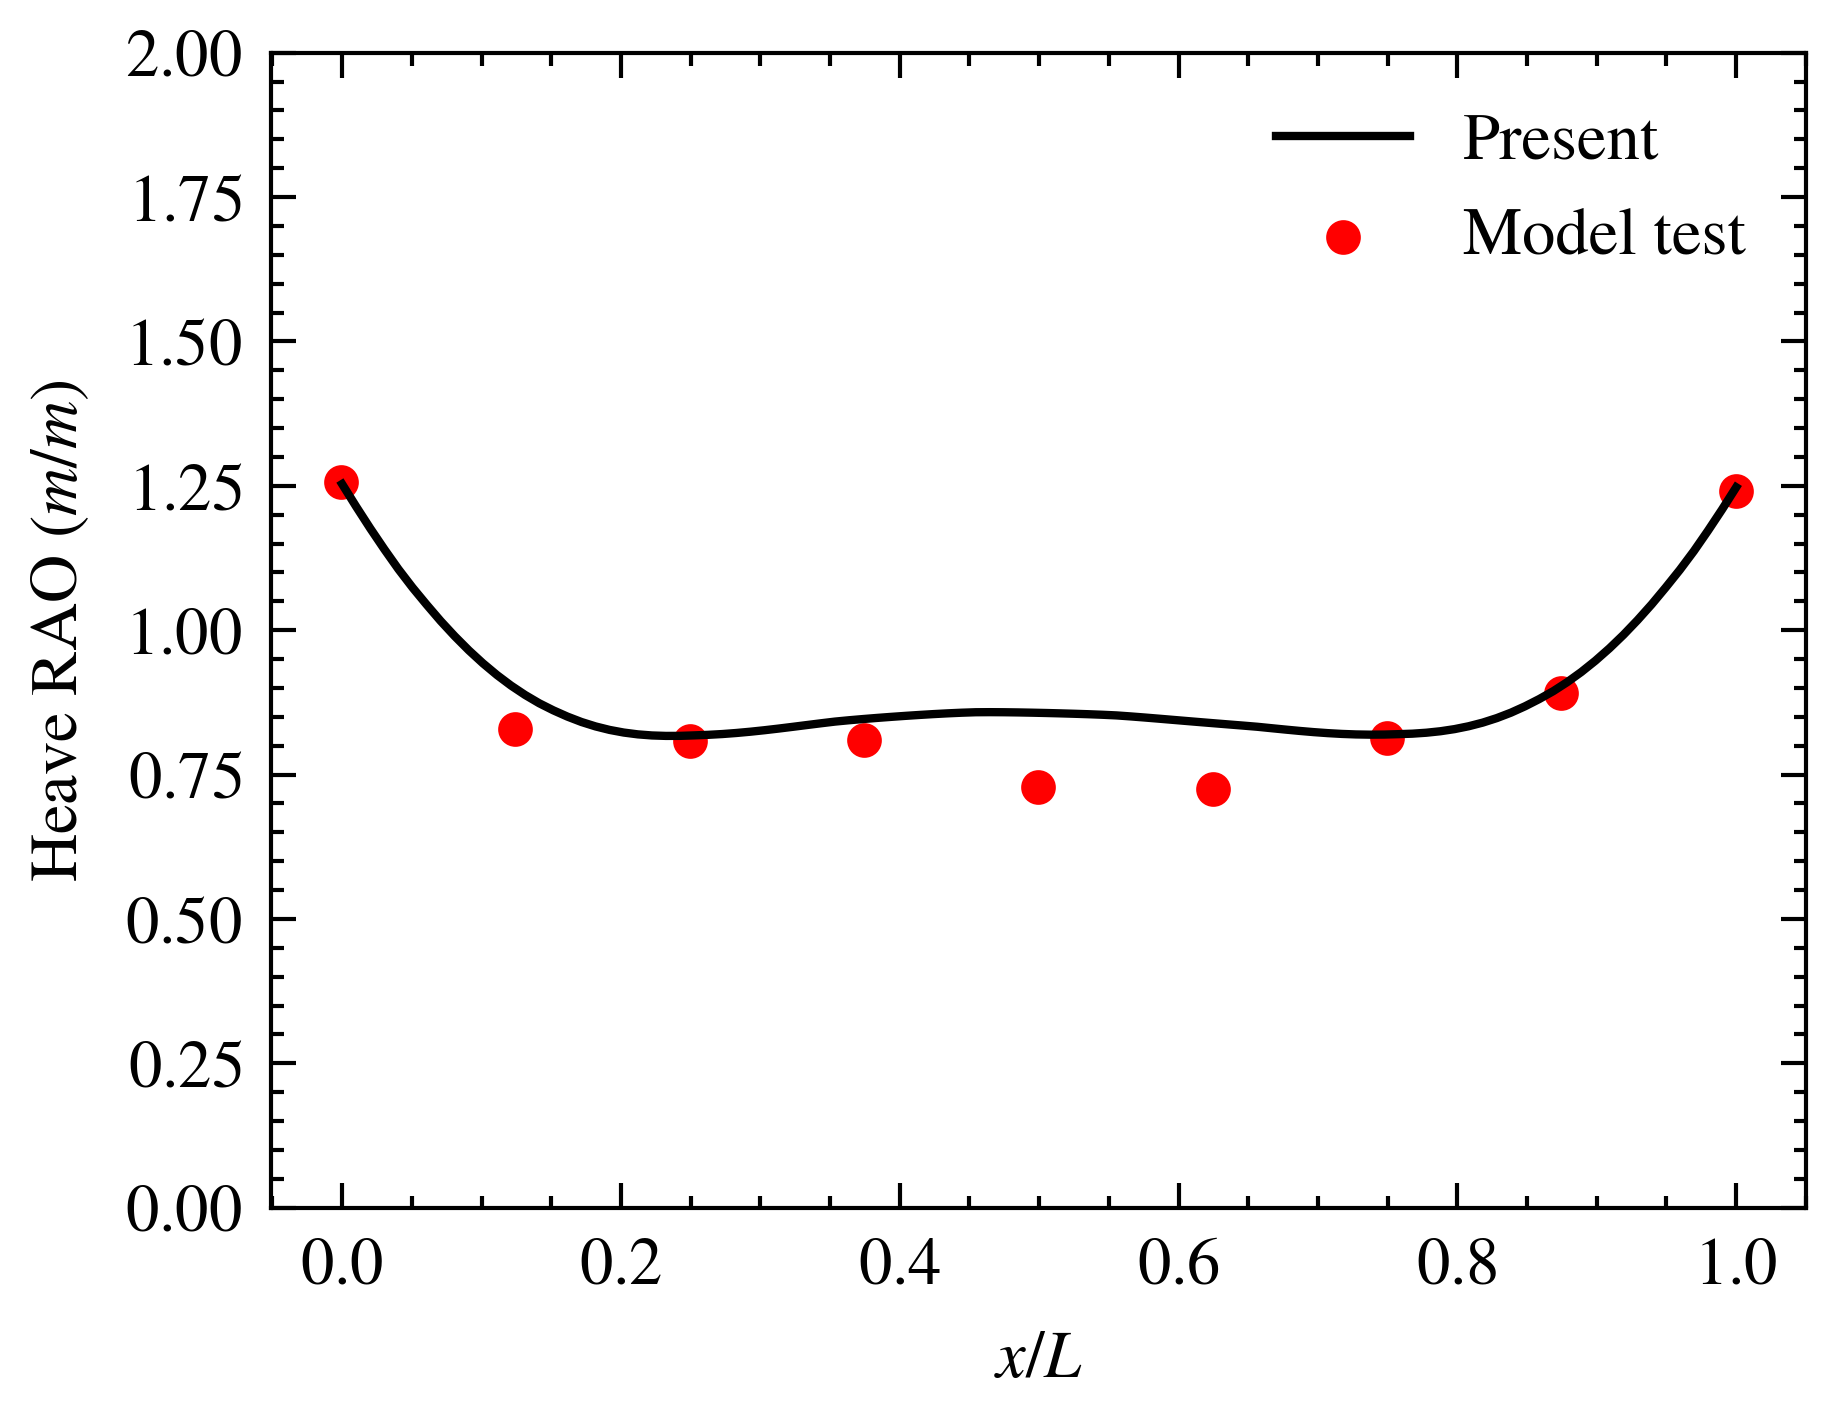

In [43]:
import matplotlib.pyplot as plt
mid = global_displacement[1011*5-5:1111*5-5,:]
heave = abs(mid[2::5])

# 与实验结果进行对比、绘图
from DM_Verify import process_exp_data
x, y = process_exp_data("E:\phd\Code\DM-FEM2D\data\Experiment_300_60\exp_300.txt")
y = np.array(y)
# 绘图
import scienceplots
x1 = np.linspace(0,1,100)
plt.style.use(['science','no-latex','ieee'])
plt.plot(x1,abs(mid[2::5]), label="Present")
plt.scatter(x,y,color = 'red',label="Model test",s=10)
plt.legend() 
plt.ylim(0,2) # 调整y轴坐标
plt.xlabel(r'$x/L$',)
plt.ylabel(r'Heave RAO ($m$/$m$)')

### 对比三种网格下的位移情况+试验结果

In [48]:
# 定义变量
number = 240

# 使用变量来构建文件路径
mesh33_path = f"E:\phd\Code\DM-FEM2D\FEM_Reduce\displacement_33mesh_300.npy"
mesh55_path = f"E:\phd\Code\DM-FEM2D\FEM_Reduce\displacement_55mesh_300.npy"
mesh_coarse_path = f"E:\phd\Code\DM-FEM2D\FEM_Reduce\displacement_1530mesh_300.npy"

# 加载文件
mesh33 = np.load(mesh33_path)
mesh55 = np.load(mesh55_path)
mesh_coarse = np.load(mesh_coarse_path)


mid33 = mesh33[1011*5-5:1111*5-5,:]
heave33 = abs(mid33[2::5])

mid55 = mesh55[367*5-5:427*5-5,:]
heave55 = abs(mid55[2::5])

mid_coarse = mesh_coarse[22*5-5:43*5-5,:]
heave_coarse = abs(mid_coarse[2::5])

x33 = np.linspace(0,1,100)
x55 = np.linspace(0,1,60)
x_coarse = np.linspace(0,1,21)

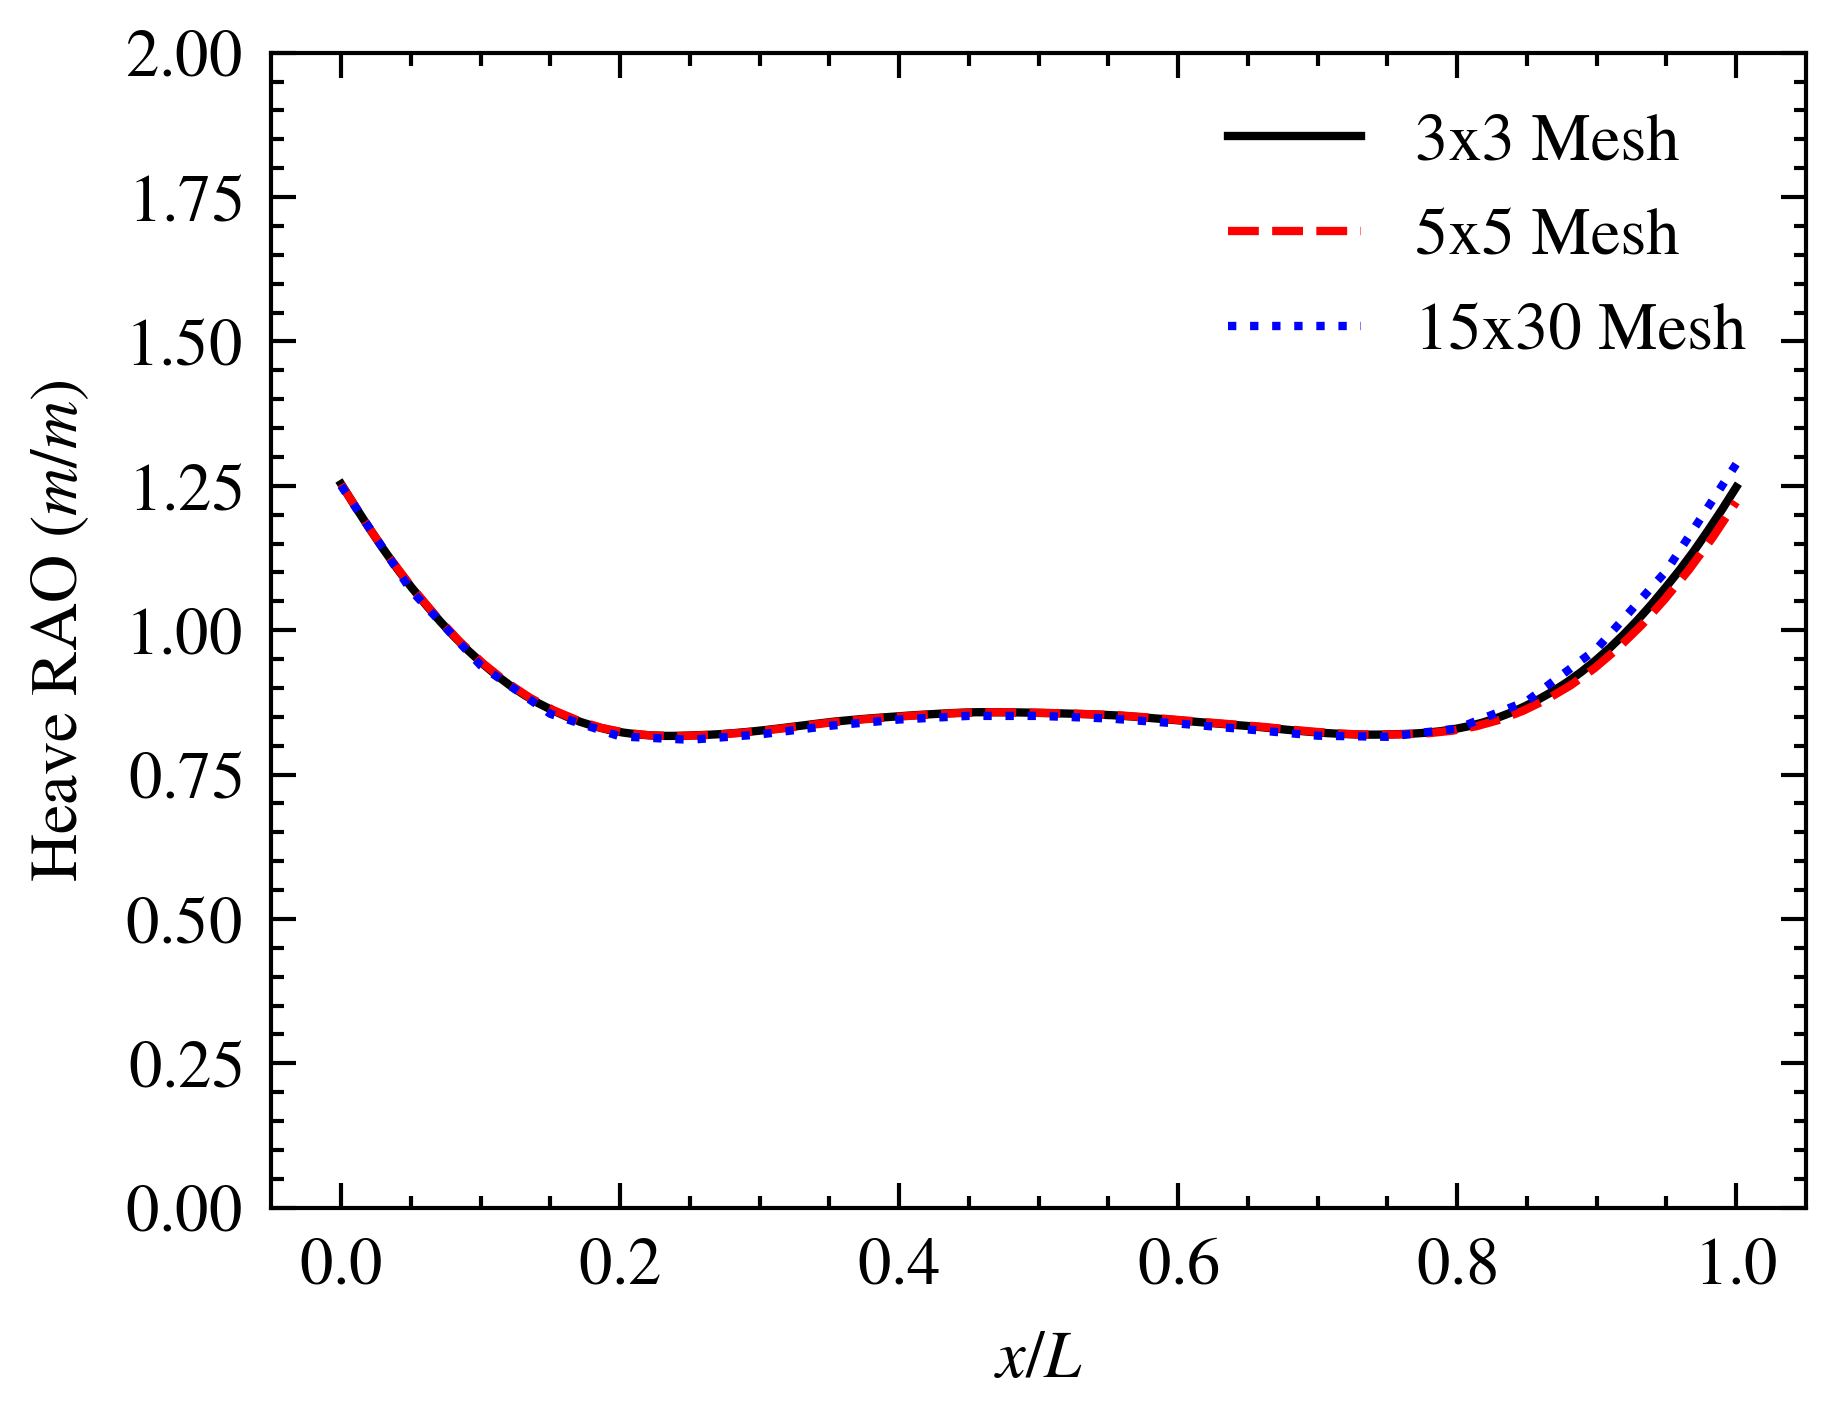

In [49]:
import scienceplots
# x, y = process_exp_data(f"E:\phd\Code\DM-FEM2D\data\Experiment_300_60\exp_{number}.txt")
# y = np.array(y)

plt.style.use(['science','no-latex','ieee'])
plt.plot(x33,heave33, label="33mesh")
plt.plot(x55,heave55, label="55mesh")
plt.plot(x_coarse,heave_coarse, label="coarse")
# plt.scatter(x,y,label="Model test",s=10)
plt.legend(['3x3 Mesh', '5x5 Mesh', '15x30 Mesh', 'Experiment'])
plt.ylim(0,2) # 调整y轴坐标
plt.xlabel(r'$x/L$',)
plt.ylabel(r'Heave RAO ($m$/$m$)')
plt.savefig(f"E:\\phd\\Code\\DM-FEM2D\\FEM_Reduce\\Date\\mesh_test\\{number}.pdf", dpi=600)